In [4]:
import warnings
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
from palettable.cartocolors.diverging import Geyser_5_r
from palettable.cartocolors.qualitative import Safe_3, Antique_5, Vivid_7
from palettable.cubehelix import cubehelix3_16
from matplotlib.patches import Patch

### 1. Init

In [9]:
# Optional inline settings for notebooks
if 'get_ipython' in globals():
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', 'InlineBackend.figure_format = "retina"')

# Suppress warnings
warnings.filterwarnings('ignore')

# Set working directory
current_dir = os.getcwd()
fhn_dir = os.path.abspath(os.path.join(current_dir, '..'))
os.chdir(fhn_dir)
sys.path.insert(1, 'Codes/')

from myUtils import *

# Helper functions
def make_path(window, year):
    return os.path.join(fhn_dir, 'Data', 'OUTPUT', 'FAC', f'FAC_{window}_{year}.tif')

def get_custom_colormap(values, base_colors):
    n_colors = len(values)
    segmented_cmap = LinearSegmentedColormap.from_list("custom", base_colors, N=n_colors - 1)
    colors = [segmented_cmap(i / (n_colors - 2)) for i in range(n_colors - 1)]
    return ListedColormap(colors), BoundaryNorm(values, ncolors=n_colors, clip=True)

### 2. Parameters

In [14]:
window = 50
year = 2020
values = [0, 0.001, 0.05, 0.5, 5, 100, 1500, 10000]

### 3. Load Data

In [ ]:
# Load raster data
file_raster_path = make_path(window, year)
data, src = read_raster(file_raster_path)
if src.crs.to_epsg() != 4326:
    data, src = reproject_raster_to_4326(src)

# Load shapefile and dataframe for bar plot
shapef = os.path.join(fhn_dir, 'Data/SHAPEFILES/world-custom_regions_r.shp')
gdf1 = gpd.read_file(shapef).to_crs("ESRI:54009")
dfData = return_df(make_path(window, year), gdf1)

### 4. Define plots features

In [10]:
# Create colormap and normalization
grey_cmap, norm = get_custom_colormap(values, Geyser_5_r.mpl_colors)

# Define colors for bar chart
CONTINENT_COLORS = {
    'Asia': Antique_5.hex_colors[0],
    'Africa': Safe_3.hex_colors[2],
    'Europe': cubehelix3_16.hex_colors[3],
    'America': Antique_5.hex_colors[3],
    'Oceania': Vivid_7.hex_colors[5]
}

# Process data for bar plot
dfData2020 = dfData[dfData['year'] == 2020].reset_index(drop=True)
dfData2020 = dfData2020.sort_values(by='median').reset_index(drop=True)
dfData2020['median'] *= 100

assert set(dfData2020['region']).issubset(REGION_TO_CONTINENT), "Missing region-to-continent mappings"
colors1 = dfData2020['region'].map(REGION_TO_CONTINENT).map(CONTINENT_COLORS)

# Legend patches
legend_patches = [
    Patch(color=grey_cmap(i / (len(values) - 2)), label=rf'$\mathrm{{{values[i]}}} \leq \mathrm{{FAC}} < \mathrm{{{values[i+1]}}}$')
    for i in range(len(values) - 1)
]

continent_patches = [Patch(color=color, label=continent) for continent, color in CONTINENT_COLORS.items()]

### 5. Plot

Text(0.01, 0.975, 'B')

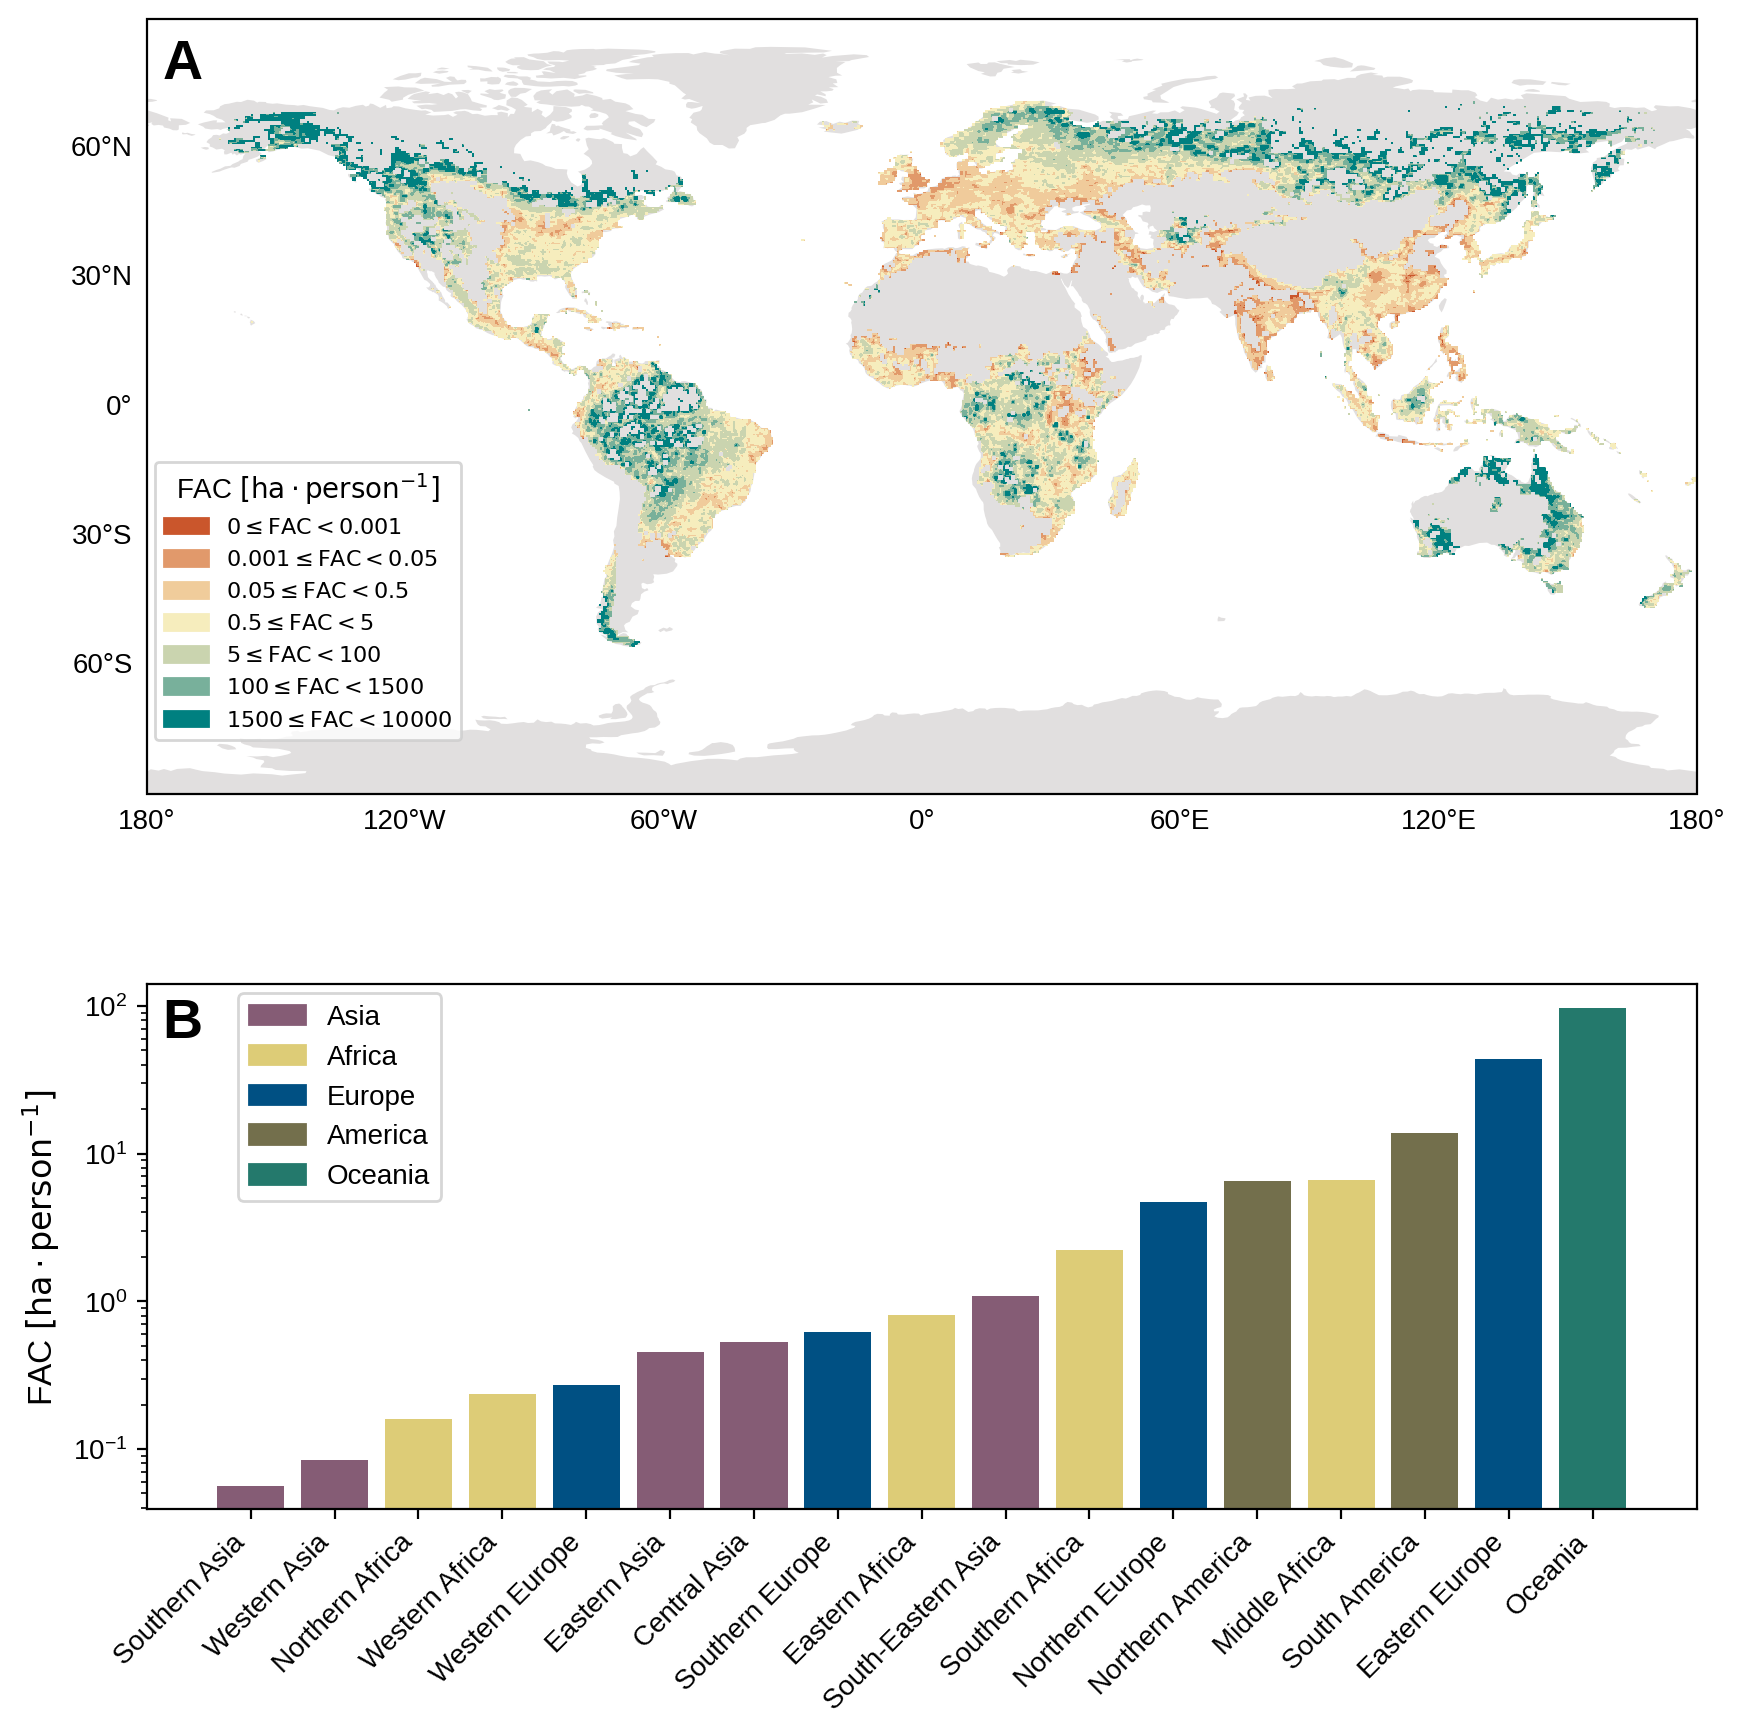

In [26]:
# Plotting
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[2, 1.2])

# Map subplot
ax1 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax1.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.OCEAN, facecolor='white')
ax1.add_feature(cfeature.LAND, facecolor='#e1dfdf')
show(data * 100, transform=src.transform, ax=ax1, cmap=grey_cmap, norm=norm)
gl = ax1.gridlines(draw_labels=True)
gl.xlines = gl.ylines = False
gl.top_labels = gl.right_labels = False
add_legend(ax1, legend_patches, 'FAC ' + r'$[\mathrm{ha} \cdot \mathrm{person}^{-1}]$', 0.21, 0.25)
ax1.text(.01, .975, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top')

# Barplot subplot
ax2 = fig.add_subplot(gs[1])
ax2.bar(dfData2020['region'], dfData2020['median'], color=colors1)
ax2.set_ylabel('FAC ' + r'$[\mathrm{ha} \cdot \mathrm{person}^{-1}]$', size=12)
ax2.set_yscale('log')
ax2.set_xticks(range(len(dfData2020['region'])))
ax2.set_xticklabels(dfData2020['region'], rotation=45, ha='right')
ax2.legend(handles=continent_patches, bbox_to_anchor=(.05, 1.01), loc='upper left', fontsize=10)
ax2.text(0.01, .975, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top')

#plt.tight_layout()
#plt.show()


In [24]:
fout = os.path.join(fhn_dir, 'Figures/Figure1AB_new.pdf')
fig.savefig(fout, dpi=300, bbox_inches='tight')